# ST-GCN: Spatial Temporal Graph Convolutional Network

In [ ]:
# Librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

# Implementación de la arquitectura

## Definición de la Capa de Convolución Espacial (GCN)

In [57]:
class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A_partitions):
        super().__init__()
        self.K = len(A_partitions)  # Número de particiones (K=3)
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1) 
            for _ in range(self.K)
        ])
        self.register_buffer('A', A_partitions) # A_partitions es la matriz A normalizada

    def forward(self, x):
        # x tiene forma (N, C_in, T, V), donde V=33 (keypoints)
        output = None
        for k in range(self.K):
            # 1. Multiplicación del feature map por la matriz A_k
            # torch.einsum realiza (N, C_in, T, V) @ (V, V) -> (N, C_in, T, V)
            # donde V x V es la matriz A_k (aplicando la adyacencia)
            x_neighbor = torch.einsum('nctv,vw->nctw', (x, self.A[k]))
            
            # 2. Convolución 1x1 (aplicando W_k)
            z = self.convs[k](x_neighbor) 

            # 3. Sumar los resultados de las K particiones
            output = z if output is None else output + z
        
        return output

## Definición de la Capa de Convolución Temporal (TCN)

In [58]:
class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, A_partitions, dropout=0.5):
        super().__init__()
        
        T_kernel, V_kernel = kernel_size
        
        # 1. GCN (Espacial) - PRIMERO
        # Se encarga de transformar la dimensión de canales (in -> out)
        self.gcn = SpatialGraphConv(in_channels, out_channels, A_partitions)
        
        # 2. TCN (Temporal) - SEGUNDO
        # Mantiene los canales (out -> out)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels), # BN antes o después de ReLU (aquí estilo Pre-activation para TCN)
            nn.ReLU(),
            nn.Conv2d(
                out_channels, 
                out_channels, 
                kernel_size=(T_kernel, 1), 
                padding=(T_kernel // 2, 0)
            ),
            nn.BatchNorm2d(out_channels), # Normalizar salida temporal
            nn.Dropout(dropout) # Regularización vital
        )
        
        # 3. Residual (Skip Connection)
        # Si los canales cambian, usamos una conv 1x1 para adaptar
        if in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (N, C_in, T, V)

        # A. Rama Residual
        res = self.residual(x)

        # B. Rama Principal (GCN -> TCN)
        
        # 1. Espacial
        x_gcn = self.gcn(x) 
        
        # 2. Temporal (incluye BN, ReLU y Dropout internamente)
        x_tcn = self.tcn(x_gcn)

        # C. Suma y Activación Final
        return self.relu(x_tcn + res)

In [59]:
class STGCN_Model(nn.Module):
    def __init__(self, num_classes, A_partitions):
        super().__init__()
        
        # Parámetros fijos para MediaPipe Pose (x, y)
        self.C = 2 # Coordenadas x, y
        self.V = 33 # Keypoints/Nodos
        
        # El resto de la arquitectura STGCN sigue igual
        # Asumimos que el primer bloque STGCN recibe 2 canales (x, y)
        self.st_gcn_stack = nn.Sequential(
            STGCN_Block(self.C, 64, (9, 1), A_partitions),
            STGCN_Block(64, 64, (9, 1), A_partitions),
            STGCN_Block(64, 128, (9, 1), A_partitions),
            # ... otros bloques ...
        )

        self.out_channels = 128 
        self.classifier = nn.Linear(self.out_channels, num_classes)

    # ----------------------------------------------------
    # MÉTODOS PRIVADOS PARA DESACOPLAR FUNCIONALIDADES
    # ----------------------------------------------------

    def _create_mask(self, x_in):
        """ Genera la máscara (N, T) a partir de los ceros de padding. """
        sum_features = torch.sum(x_in, dim=2) 
        mask = (sum_features != 0)
        return mask.float()
    
    def _prep_input(self, x_in):
        """ Realiza el Reshape y Permute para preparar el tensor para ST-GCN. """
        N, T, F = x_in.shape
        
        # Reshape: (N, T, 66) -> (N, T, C, V)
        x = x_in.reshape(N, T, self.C, self.V) 
        
        # Permute: (N, T, C, V) -> (N, C, T, V)
        x = x.permute(0, 2, 1, 3) 
        return x

    def _pool_and_classify(self, x, mask):
        """ Aplica Global Average Pooling con masking y realiza la clasificación final. """
        
        # 1. Preparar la Máscara para Broadcasting (N, 1, T, 1)
        mask_4d = mask.unsqueeze(1).unsqueeze(3) 
        
        # 2. Aplicar Máscara y Sumar
        # Multiplicamos la salida final por la máscara para anular el padding
        x_masked = x * mask_4d
        sum_features = x_masked.sum(dim=(2, 3)) # Suma sobre T y V -> (N, C_out)

        # 3. Normalizar (Contar Nodos Válidos)
        valid_frames_count = mask.sum(dim=1) # Suma sobre T -> Forma (N,)
        total_valid_nodes = (valid_frames_count * self.V).unsqueeze(1) # Forma (N, 1)
        
        # 4. Calcular el Promedio Válido (Evitando división por cero)
        x_pooled = sum_features / (total_valid_nodes + 1e-8) 

        # 5. Clasificar
        return self.classifier(x_pooled)

    # ----------------------------------------------------
    # F U N C I Ó N   F O R W A R D   (LIMPIA)
    # ----------------------------------------------------
    def forward(self, x_in):
        # x_in tiene la forma (N, T, 66)

        # 1. Preprocesamiento: Generar la máscara y reestructurar el tensor
        mask = self._create_mask(x_in)
        x = self._prep_input(x_in)

        # 2. Procesamiento Núcleo ST-GCN
        # NOTA: Los bloques TCN/GCN dentro del Sequential NO necesitan el masking
        # ya que la pérdida por el padding se corrige en el pooling final.
        x = self.st_gcn_stack(x)
        
        # 3. Post-procesamiento: Pooling y Clasificación
        return self._pool_and_classify(x, mask)

1. **Preparación y Formato de los Datos.**

El formato de entrada para ST-GCN es crucial y difiere de los DataFrames planos que tienes. Necesitas convertir tus datos en un tensor con las dimensiones específicas que la red convolucional maneja.

*Reestructurar los Datos*: Toma tus landmarks originales (o los ángulos, si los prefieres, aunque ST-GCN funciona mejor con coordenadas) para cada secuencia (ejemplo de flexión).
    * Un conjunto de datos de pose (coordenadas $x, y$) debe tener la forma:$$\text{Input: } (\mathbf{N}, \mathbf{C}, \mathbf{T}, \mathbf{V})$$$\mathbf{N}$: Número de secuencias (el batch size).$\mathbf{C}$: Canales (features por nodo, típicamente 2 para $(x, y)$ o 3 para $(x, y, z)$).$\mathbf{T}$: Dimensión temporal (número de frames en la secuencia).$\mathbf{V}$: Nodos (keypoints o articulaciones, 33 para MediaPipe Pose).

Ventana de Tiempo (Sequence Truncation):Dado que las secuencias de ejercicio pueden tener diferentes longitudes, es común cortarlas o padearlas a una longitud fija $\mathbf{T}$ (ej., 50 frames). Esto asegura que todos los tensors de entrada tengan la misma forma.Matriz de Adyacencia ($A$):Debes crear y normalizar la matriz $33 \times 33$ que define las conexiones esqueléticas. Esta matriz se alimenta al modelo y se usa en cada capa GCN.

### Construcción de la matriz de adyacencia

In [60]:
import numpy as np

def build_mediapipe_adjacency_matrix(num_keypoints=33):
    """
    Construye la matriz de adyacencia (A_ADJ) para los 33 keypoints de MediaPipe Pose.
    """
    
    # Definición de los bordes del esqueleto (pares de índices conectados)
    # Se incluyen conexiones para cabeza/ojos/orejas para una matriz de 33 nodos.
    # Esta lista de bordes define la estructura de las extremidades y el tronco.
    EDGES = [
        # Cabeza y Tronco Central
        (0, 1), (1, 2), (2, 3), (3, 7), (4, 5), (5, 6), (6, 8), # Ojos, Nariz, Orejas
        (9, 10), (11, 12), (23, 24), # Boca, Hombros, Caderas
        
        # Conexiones Hombro/Cadera/Tronco
        (11, 23), (12, 24), (11, 12), (23, 24), # Tronco (Hombro-Cadera, Hombro-Hombro, Cadera-Cadera)

        # Brazo Izquierdo
        (11, 13), (13, 15), (15, 17), (17, 19), (19, 21), # Hombro I -> Muñeca I -> Dedos
        
        # Brazo Derecho
        (12, 14), (14, 16), (16, 18), (18, 20), (20, 22), # Hombro D -> Muñeca D -> Dedos
        
        # Pierna Izquierda
        (23, 25), (25, 27), (27, 29), (29, 31), # Cadera I -> Pie I
        
        # Pierna Derecha
        (24, 26), (26, 28), (28, 30), (30, 32), # Cadera D -> Pie D
        
        # Conexión cruzada entre lados (muñecas)
        (15, 17), (16, 18),
    ]

    # Inicializar la matriz de adyacencia (33x33) con ceros
    A_ADJ = np.zeros((num_keypoints, num_keypoints), dtype=np.float32)

    # Llenar la matriz con las conexiones (bordes)
    for i, j in EDGES:
        # Poner 1 para la conexión (i -> j) y (j -> i) (grafo no dirigido)
        if 0 <= i < num_keypoints and 0 <= j < num_keypoints:
            A_ADJ[i, j] = 1.0
            A_ADJ[j, i] = 1.0

    return A_ADJ

# Generar la matriz de adyacencia
A_ADJ_RAW = build_mediapipe_adjacency_matrix()

print(f"La matriz de adyacencia RAW tiene forma: {A_ADJ_RAW.shape}")

La matriz de adyacencia RAW tiene forma: (33, 33)


### Matriz de particiones para ST-GCN

In [61]:
def normalize_adjacency(A_adj):
    """
    Calcula la matriz de adyacencia normalizada simétrica (D^-1/2 * A' * D^-1/2).
    """
    # 1. Añadir el lazo propio (self-loop): A' = A + I
    A_prime = A_adj + np.eye(A_adj.shape[0])
    
    # 2. Calcular la matriz de grado D (suma de filas)
    D = np.sum(A_prime, axis=1)
    
    # 3. Calcular D^-1/2
    D_half_norm = np.diag(D ** (-0.5))
    
    # 4. Calcular A_norm = D^-1/2 * A' * D^-1/2
    A_norm = D_half_norm @ A_prime @ D_half_norm
    
    # Devolver como tensor PyTorch (asumiendo que STGCN_Model usa K=1 partición)
    return torch.tensor(A_norm, dtype=torch.float32)

# La matriz A normalizada para un modelo K=1:
A_NORM_TENSOR = normalize_adjacency(A_ADJ_RAW)

# Para usar en el modelo STGCN_Model_Adapted (con K=1), pasaríamos un tensor de forma (1, V, V)
A_PARTITIONS_K1 = A_NORM_TENSOR.unsqueeze(0) 

print(f"\nLa matriz normalizada (para K=1) tiene forma: {A_PARTITIONS_K1.shape}")


La matriz normalizada (para K=1) tiene forma: torch.Size([1, 33, 33])


### Ejemplo de uso del modelo

In [62]:
import torch
import torch.nn as nn
import numpy as np
# Necesitas las clases SpatialGraphConv, STGCN_Block, STGCN_Model definidas previamente
# (Asumiendo que las has cargado o copiado en tu entorno)

# --- Definición de clases (Simplificada para el ejemplo) ---
# En un script real, estas clases deben estar definidas, las hemos omitido aquí
# para concentrarnos en la simulación I/O.
# (Puedes usar la definición anterior para las clases STGCN_Block, SpatialGraphConv, y STGCN_Model)
# -----------------------------------------------------------

# 1. Definición de Parámetros de Entrada
BATCH_SIZE = 32
CHANNELS = 2     # x, y coordinates
TIME_STEPS = 50  # 50 frames per sequence
VERTICES = 33    # 33 MediaPipe keypoints
NUM_CLASSES = 2  # 0: Incorrecto, 1: Correcto

# 2. Simulación de la Matriz de Adyacencia (A)
# ST-GCN usa múltiples particiones de A. Aquí simulamos una simple matriz de 3 particiones (K=3).
# En un entorno real, A_PARTITIONS debe ser una matriz de adyacencia real, normalizada y triparticionada.
A_ADJ = torch.eye(VERTICES) # Matriz identidad para simular auto-conexión
A_PARTITIONS = torch.stack([A_ADJ, A_ADJ, A_ADJ], dim=0) # Forma (K, V, V) -> (3, 33, 33)

# 3. Creación del Tensor de Entrada Simulada (X)
# Generamos datos aleatorios con la forma requerida: (N, C, T, V)
# Estos datos simularían 32 secuencias de 50 frames, cada frame con 33 keypoints (x, y).
X_simulated = torch.randn(BATCH_SIZE, TIME_STEPS, VERTICES * CHANNELS)
print(f"Shape de la Entrada X: {X_simulated.shape}")

# 4. Inicialización del Modelo
# (Requiere que las clases STGCN estén definidas)
try:
    model = STGCN_Model(
        num_classes=NUM_CLASSES, 
        A_partitions=A_PARTITIONS
    )
    print("Modelo ST-GCN inicializado correctamente.")
    
    # 5. Paso Adelante (Forward Pass)
    output = model(X_simulated)
    
    # 6. Salida del Modelo (Predicciones)
    print(f"Shape de la Salida Y: {output.shape}")
    
    # Ejemplo de la primera predicción del batch
    print("\nPredicción de la primera secuencia (Logits/Scores):")
    print(output[0])
    
    # Aplicar Softmax para obtener probabilidades
    y_pred_proba = nn.Softmax(dim=1)(output)
    
    # La clase predicha es el índice con la probabilidad más alta
    predicted_class = torch.argmax(y_pred_proba, dim=1)
    
    print("\nProbabilidades de las 3 primeras secuencias:")
    print(y_pred_proba[:3])
    print(f"Clase Predicha para las 3 primeras secuencias: {predicted_class[:3].tolist()}")

except NameError as e:
    print("\n⚠️ Por favor, asegúrate de que las clases 'SpatialGraphConv', 'STGCN_Block', y 'STGCN_Model' de la respuesta anterior estén definidas en tu script antes de ejecutar la simulación.")
    raise e

Shape de la Entrada X: torch.Size([32, 50, 66])
Modelo ST-GCN inicializado correctamente.
Shape de la Salida Y: torch.Size([32, 2])

Predicción de la primera secuencia (Logits/Scores):
tensor([-0.1269, -0.4702], grad_fn=<SelectBackward0>)

Probabilidades de las 3 primeras secuencias:
tensor([[0.5850, 0.4150],
        [0.5896, 0.4104],
        [0.5832, 0.4168]], grad_fn=<SliceBackward0>)
Clase Predicha para las 3 primeras secuencias: [0, 0, 0]


# Entrenamiento del modelo

In [63]:
!git clone https://github.com/victorlopez-ds/push-up-video-classification.git

Cloning into 'push-up-video-classification'...
remote: Enumerating objects: 346, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 346 (delta 4), reused 10 (delta 2), pack-reused 334 (from 1)
Receiving objects: 100% (346/346), 110.61 MiB | 14.80 MiB/s, done.
Resolving deltas: 100% (49/49), done.


### Implementación del dataset y el dataloader

In [64]:
%cd push-up-video-classification/

/content/push-up-video-classification/push-up-video-classification/push-up-video-classification


In [65]:
# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

In [66]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [67]:
BATCH_SIZE = 32 # Número de secuencias por lote

# Crea el objeto Dataset (combina X y Y)
train_dataset = TensorDataset(X_train, y_train)

# Crea el DataLoader (se encarga de iterar, barajar y cargar por lotes)
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True # Barajar los datos en cada época para evitar sesgos
)

# Puedes hacer lo mismo para el conjunto de validación
val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Número de lotes de entrenamiento: {len(train_dataloader)}")

Número de lotes de entrenamiento: 3


In [68]:
import torch

# Define el dispositivo de ejecución
# Si CUDA (NVIDIA GPU) está disponible, usa la GPU; si no, usa la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Asegúrate de enviar tu modelo al dispositivo
# model.to(device)

Usando dispositivo: cuda


In [69]:
import matplotlib.pyplot as plt
import numpy as np
# Necesitas también el 'val_dataloader' (cargador de datos de validación)

# --- INICIALIZACIÓN DE LISTAS ---
train_losses = []
val_losses = [] # Para almacenar la pérdida de validación

# Inicialización
NUM_EPOCHS = 50
LR = 5*1e-4
model = STGCN_Model(num_classes=2, A_partitions=A_PARTITIONS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


for epoch in range(NUM_EPOCHS):
    
    # ----------------------------------------
    # FASE DE ENTRENAMIENTO
    # ----------------------------------------
    model.train() 
    epoch_train_loss = 0
    
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 1. Acumular la pérdida
        epoch_train_loss += loss.item() * inputs.size(0) 

        loss.backward() 
        optimizer.step()
    
    # Calcular la pérdida promedio de entrenamiento por época
    avg_train_loss = epoch_train_loss / len(train_dataloader.dataset)
    train_losses.append(avg_train_loss)
    
    # ----------------------------------------
    # FASE DE VALIDACIÓN (Crucial para detectar Overfitting)
    # ----------------------------------------
    model.eval() # Pone el modelo en modo evaluación (desactiva dropout/batchnorm)
    epoch_val_loss = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y tiempo
        for inputs_val, labels_val in val_dataloader:
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            
            # 2. Acumula la pérdida de validación
            epoch_val_loss += loss_val.item() * inputs_val.size(0)
            
    # Calcular la pérdida promedio de validación por época
    avg_val_loss = epoch_val_loss / len(val_dataloader.dataset)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/50, Train Loss: 0.6671, Val Loss: 0.6706
Epoch 2/50, Train Loss: 0.5449, Val Loss: 0.7131
Epoch 3/50, Train Loss: 0.5153, Val Loss: 0.8244
Epoch 4/50, Train Loss: 0.4896, Val Loss: 0.9417
Epoch 5/50, Train Loss: 0.4776, Val Loss: 1.1089
Epoch 6/50, Train Loss: 0.4789, Val Loss: 1.1841
Epoch 7/50, Train Loss: 0.4607, Val Loss: 1.4180
Epoch 8/50, Train Loss: 0.4668, Val Loss: 1.6169
Epoch 9/50, Train Loss: 0.4758, Val Loss: 1.4676
Epoch 10/50, Train Loss: 0.4755, Val Loss: 1.2785
Epoch 11/50, Train Loss: 0.4682, Val Loss: 1.2859
Epoch 12/50, Train Loss: 0.4342, Val Loss: 1.1391
Epoch 13/50, Train Loss: 0.4152, Val Loss: 1.0830
Epoch 14/50, Train Loss: 0.4797, Val Loss: 1.0447
Epoch 15/50, Train Loss: 0.4427, Val Loss: 1.5534
Epoch 16/50, Train Loss: 0.4090, Val Loss: 1.0963
Epoch 17/50, Train Loss: 0.3996, Val Loss: 0.8293
Epoch 18/50, Train Loss: 0.3951, Val Loss: 0.6957
Epoch 19/50, Train Loss: 0.3722, Val Loss: 0.6304
Epoch 20/50, Train Loss: 0.3580, Val Loss: 0.6541
Epoch 21/

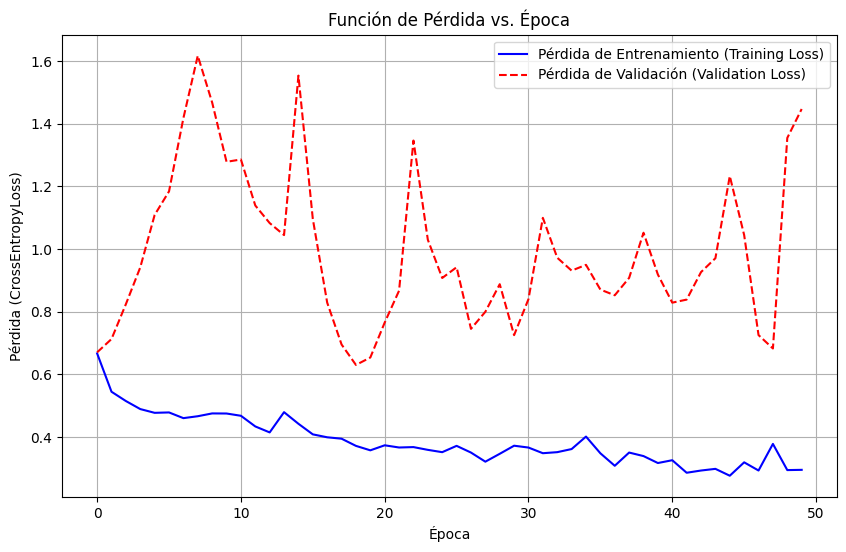

In [70]:
## --- CÓDIGO DE VISUALIZACIÓN ---

plt.figure(figsize=(10, 6))

# Trazar la pérdida de entrenamiento
plt.plot(train_losses, label='Pérdida de Entrenamiento (Training Loss)', color='blue')

# Trazar la pérdida de validación
plt.plot(val_losses, label='Pérdida de Validación (Validation Loss)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Función de Pérdida vs. Época')
plt.xlabel('Época')
plt.ylabel('Pérdida (CrossEntropyLoss)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluación

Iniciando evaluación...

🎯 Accuracy Global: 60.00%

📊 Reporte de Clasificación:
              precision    recall  f1-score   support

  Incorrecto       0.50      1.00      0.67         8
    Correcto       1.00      0.33      0.50        12

    accuracy                           0.60        20
   macro avg       0.75      0.67      0.58        20
weighted avg       0.80      0.60      0.57        20



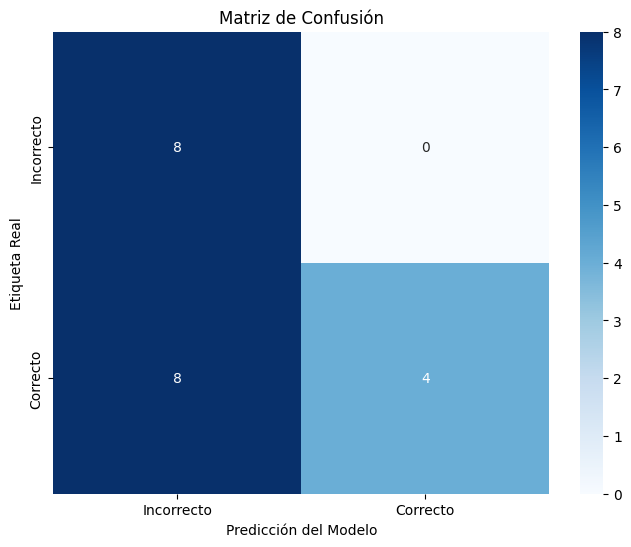

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model(model, dataloader, device, class_names=['Incorrecto', 'Correcto']):
    """
    Evalúa el modelo y genera métricas y gráficos detallados.
    """
    model.eval() # 1. Apaga Dropout y BatchNormalization
    
    all_preds = []
    all_labels = []
    
    print("Iniciando evaluación...")
    
    with torch.no_grad(): # 2. Desactiva el cálculo de gradientes (ahorra memoria)
        for batch in dataloader:
            # Manejo flexible: si el dataloader devuelve mask o no
            if len(batch) == 3:
                inputs, labels, mask = batch
                inputs, labels, mask = inputs.to(device), labels.to(device), mask.to(device)
                # Si tu modelo requiere mask explícita:
                # outputs = model(inputs, mask) 
                # Si tu modelo tiene auto-masking:
                outputs = model(inputs) 
            else:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs) # El modelo genera la máscara internamente

            # Obtener la clase predicha (el índice con mayor valor)
            _, preds = torch.max(outputs, 1)
            
            # Guardar predicciones y etiquetas reales en CPU
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- CÁLCULO DE MÉTRICAS ---
    
    # 3. Accuracy Global
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n🎯 Accuracy Global: {acc*100:.2f}%")
    
    # 4. Reporte Detallado (Precision, Recall, F1)
    print("\n📊 Reporte de Clasificación:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 5. Matriz de Confusión Visual
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.title('Matriz de Confusión')
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de tener definido 'test_dataloader' con datos que el modelo NO ha visto
evaluate_model(model, val_dataloader, device)

# Experimentos

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import numpy as np
import copy 

# =============================================================================
# 1. FUNCIÓN DE ENTRENAMIENTO (UNA ÉPOCA)
# =============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta el paso de entrenamiento para una sola época."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    return avg_loss, avg_acc

# =============================================================================
# 2. FUNCIÓN DE VALIDACIÓN (UNA ÉPOCA)
# =============================================================================
def validate_one_epoch(model, loader, criterion, device):
    """Ejecuta la evaluación sin calcular gradientes."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Listas para guardar predicciones (útil para el paso final del fold)
    preds_list = []
    labels_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            # Guardamos predicciones por si es la última pasada
            preds_list.extend(predicted.cpu().numpy())
            labels_list.extend(y_batch.cpu().numpy())
            
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    
    return avg_loss, avg_acc, preds_list, labels_list

# =============================================================================
# 3. GESTOR DE UN SOLO PLIEGUE (FOLD MANAGER)
# =============================================================================
def train_single_fold(model, train_loader, val_loader, epochs, lr, patience, device):
    """Entrena un modelo desde cero para un fold específico con Early Stopping."""
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    
    # Variables de Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    
    for epoch in range(epochs):
        # 1. Entrenar
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # 2. Validar
        val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)
        
        # 3. Guardar Historia
        history['loss'].append(train_loss)
        history['acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # 4. Lógica Early Stopping
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_weights = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"    ⏹️ Early stopping en época {epoch+1}")
                    break
    
    # 5. Restaurar el mejor modelo y hacer inferencia final
    if best_weights:
        model.load_state_dict(best_weights)
    
    # Hacemos una última pasada de validación con el MEJOR modelo para sacar las predicciones
    final_val_loss, final_val_acc, final_preds, final_labels = validate_one_epoch(model, val_loader, criterion, device)
    
    return final_val_acc, history, final_preds, final_labels

# =============================================================================
# 4. FUNCIÓN PRINCIPAL (ORQUESTADOR K-FOLD)
# =============================================================================
def run_kfold_experiment_pytorch(model_class, model_params, X_full, y_full, 
                                 epochs, batch_size, lr=0.001, n_splits=5, patience=None, device='cpu'):
    
    # Asegurar tipos numpy
    if isinstance(X_full, torch.Tensor): X_full = X_full.cpu().numpy()
    if isinstance(y_full, torch.Tensor): y_full = y_full.cpu().numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Acumuladores Globales
    fold_accuracies = []
    fold_histories = []
    global_y_true = []
    global_y_pred = []
    
    print(f"🚀 Iniciando K-Fold Modular ({n_splits} splits) en {device}...")
    print("===" * 20)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_full)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")
        
        # A. Preparar Tensores y Loaders
        X_train_t = torch.tensor(X_full[train_index], dtype=torch.float32)
        y_train_t = torch.tensor(y_full[train_index], dtype=torch.long)
        X_val_t = torch.tensor(X_full[val_index], dtype=torch.float32)
        y_val_t = torch.tensor(y_full[val_index], dtype=torch.long)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
        
        # B. Inicializar Modelo
        model = model_class(**model_params).to(device)
        
        # C. Delegar el trabajo sucio a la función 'train_single_fold'
        val_acc, history, fold_preds, fold_labels = train_single_fold(
            model, train_loader, val_loader, epochs, lr, patience, device
        )
        
        # D. Recolectar resultados
        print(f"    ✅ Fin Fold {fold_idx+1}. Mejor Acc Val: {val_acc:.4f}")
        
        fold_accuracies.append(val_acc)
        fold_histories.append(history)
        global_y_true.extend(fold_labels)
        global_y_pred.extend(fold_preds)

    # E. Resultados Finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    print("===" * 20)
    print(f"📊 Resultados K-Fold:")
    print(f"| Accuracy Medio: {mean_acc:.4f} (+/- {std_acc:.4f})")
    
    return mean_acc, std_acc, fold_histories, np.array(global_y_true), np.array(global_y_pred)

In [73]:
import matplotlib.pyplot as plt

def plot_kfold_history_pytorch(fold_histories, title='Métricas K-Fold ST-GCN'):
    """Grafica Loss y Accuracy promedio con sombra de desviación estándar."""
    
    if not fold_histories:
        print("Error: No hay historias para graficar.")
        return

    # Encontrar la longitud mínima (por si hubo Early Stopping en tiempos distintos)
    # Cortamos todas las gráficas a la longitud del entrenamiento más corto
    # Opcional: Podrías rellenar con NaNs, pero cortar es más limpio para visualizar.
    min_epochs = min(len(h['loss']) for h in fold_histories)
    
    print(f"Graficando las primeras {min_epochs} épocas comunes...")

    # Crear arrays para promedios
    metrics = ['loss', 'val_loss', 'acc', 'val_acc']
    data = {m: np.zeros((len(fold_histories), min_epochs)) for m in metrics}

    for i, history in enumerate(fold_histories):
        for m in metrics:
            data[m][i, :] = history[m][:min_epochs]

    # Calcular medias y desviaciones
    means = {m: np.mean(data[m], axis=0) for m in metrics}
    stds = {m: np.std(data[m], axis=0) for m in metrics}
    
    epochs_range = range(1, min_epochs + 1)

    # --- PLOT 1: LOSS ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Train Loss
    plt.plot(epochs_range, means['loss'], label='Train Loss', color='blue')
    plt.fill_between(epochs_range, means['loss'] - stds['loss'], means['loss'] + stds['loss'], color='blue', alpha=0.1)
    # Val Loss
    plt.plot(epochs_range, means['val_loss'], label='Val Loss', color='red')
    plt.fill_between(epochs_range, means['val_loss'] - stds['val_loss'], means['val_loss'] + stds['val_loss'], color='red', alpha=0.1)
    
    plt.title(f'{title} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: ACCURACY ---
    plt.subplot(1, 2, 2)
    # Train Acc
    plt.plot(epochs_range, means['acc'], label='Train Acc', color='blue')
    plt.fill_between(epochs_range, means['acc'] - stds['acc'], means['acc'] + stds['acc'], color='blue', alpha=0.1)
    # Val Acc
    plt.plot(epochs_range, means['val_acc'], label='Val Acc', color='green')
    plt.fill_between(epochs_range, means['val_acc'] - stds['val_acc'], means['val_acc'] + stds['val_acc'], color='green', alpha=0.1)
    
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## EXP-ST-GCN-01
Evaluación del modelo con K-Fold

🚀 Iniciando K-Fold Modular (5 splits) en cuda...

🔄 Pliegue 1/5
    ⏹️ Early stopping en época 67
    ✅ Fin Fold 1. Mejor Acc Val: 0.7500

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Mejor Acc Val: 0.9000

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 61
    ✅ Fin Fold 3. Mejor Acc Val: 0.7000

🔄 Pliegue 4/5
    ⏹️ Early stopping en época 38
    ✅ Fin Fold 4. Mejor Acc Val: 0.8000

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Mejor Acc Val: 1.0000
📊 Resultados K-Fold:
| Accuracy Medio: 0.8300 (+/- 0.1077)
Graficando las primeras 38 épocas comunes...


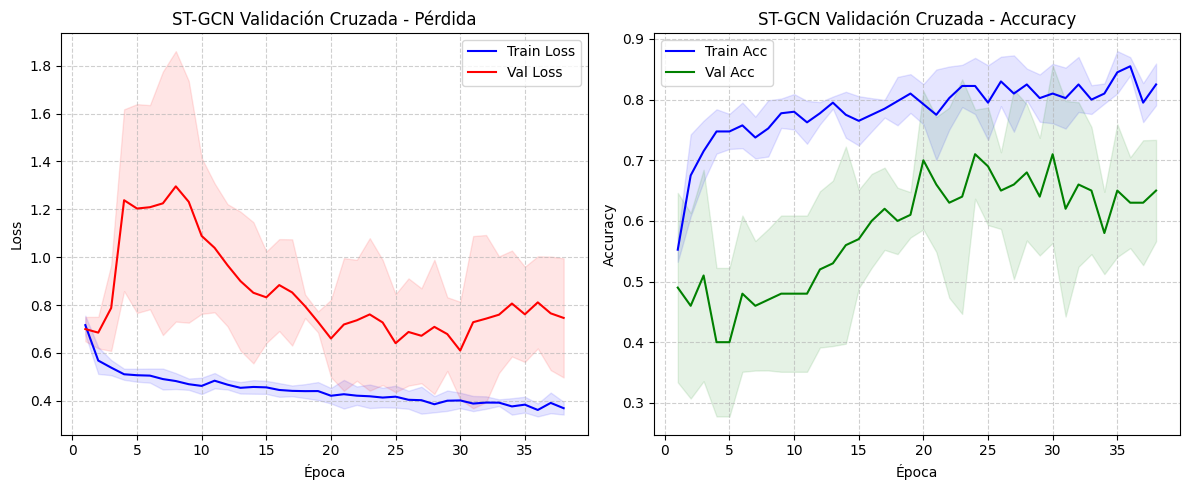

In [78]:
# 1. Definir los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al __init__ dentro del bucle
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS  # Asegúrate de tener tu matriz A definida
}

# 2. Definir tus datos (Suponiendo que ya tienes X_train y y_train)
# X_train shape: (Num_muestras, T, 66)
# y_train shape: (Num_muestras,)

# 3. Ejecutar el experimento
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor,                     # Tus datos
    y_full=y_tensor,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficar
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

### Evaluación con Bootstrapping

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import numpy as np

def calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.
    """
    stats = []
    
    # 1. Bucle de simulaciones (1000 veces)
    for i in range(n_iterations):
        # Generamos índices aleatorios con reemplazo
        # (Simula meter la mano en la bolsa y sacar bolas repetidas)
        indices = resample(range(len(y_pred)), replace=True)
        
        # Creamos el "dataset virtual"
        sample_pred = y_pred[indices]
        sample_true = y_true[indices]
        
        # Calculamos el accuracy de esta simulación
        score = accuracy_score(sample_true, sample_pred)
        stats.append(score)
    
    # 2. Ordenamos los 1000 resultados de menor a mayor
    stats = np.sort(stats)
    
    # 3. Calculamos los límites (cortamos las colas)
    lower_percentile = ((1.0 - alpha) / 2.0) * 100
    upper_percentile = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    lower = np.percentile(stats, lower_percentile)
    upper = np.percentile(stats, upper_percentile)
    
    print(f"Accuracy Promedio (Bootstrap): {np.mean(stats):.4f}")
    print(f"Intervalo de Confianza {int(alpha*100)}%: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper, stats

Accuracy Promedio (Bootstrap): 0.8300
Intervalo de Confianza 95%: [0.7500, 0.9000]


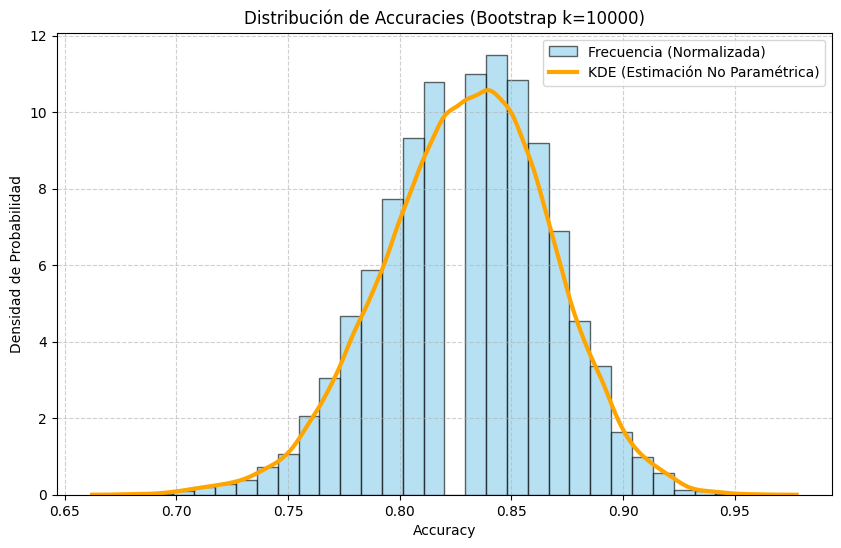

In [ ]:

# Graficamos el histograma de accuracies bootstrap
n_iterations = 10000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=15, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)')

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## EXP-ST-GCN-02

In [81]:
import torch
import numpy as np

# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/mixed_correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/mixed_wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

🚀 Iniciando K-Fold Modular (5 splits) en cuda...

🔄 Pliegue 1/5
    ⏹️ Early stopping en época 92
    ✅ Fin Fold 1. Mejor Acc Val: 0.9250

🔄 Pliegue 2/5
    ⏹️ Early stopping en época 60
    ✅ Fin Fold 2. Mejor Acc Val: 0.8750

🔄 Pliegue 3/5
    ⏹️ Early stopping en época 83
    ✅ Fin Fold 3. Mejor Acc Val: 0.8500

🔄 Pliegue 4/5
    ⏹️ Early stopping en época 68
    ✅ Fin Fold 4. Mejor Acc Val: 0.8250

🔄 Pliegue 5/5
    ⏹️ Early stopping en época 99
    ✅ Fin Fold 5. Mejor Acc Val: 0.9250
📊 Resultados K-Fold:
| Accuracy Medio: 0.8800 (+/- 0.0400)
Graficando las primeras 60 épocas comunes...


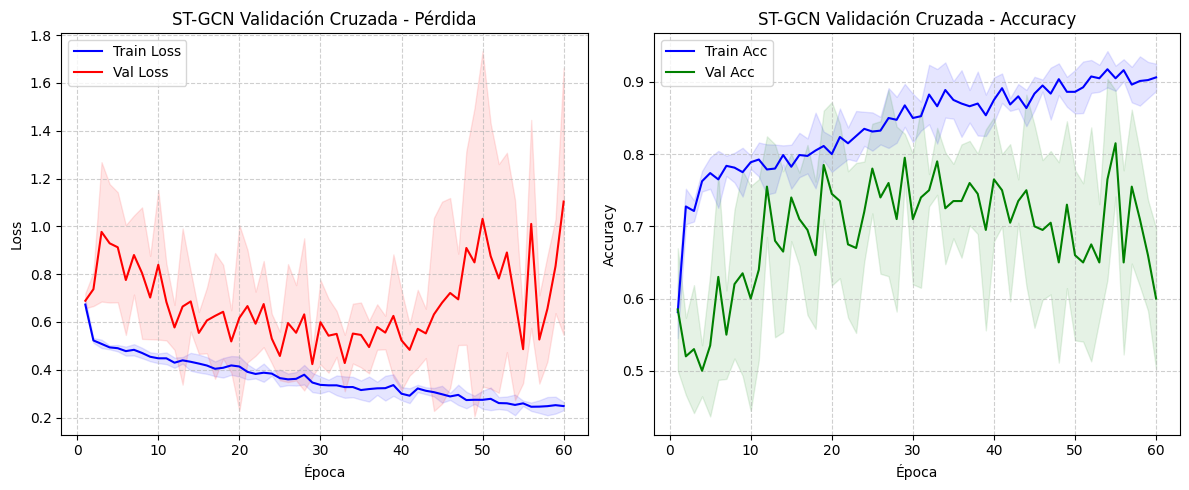

In [82]:
# 1. Definir los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al __init__ dentro del bucle
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS  
}

# 2. Definir tus datos (Suponiendo que ya tienes X_train y y_train)
# X_train shape: (Num_muestras, T, 66)
# y_train shape: (Num_muestras,)

# 3. Ejecutar el experimento
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor,                     # Tus datos
    y_full=y_tensor,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficar
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

### Evaluación con Bootstrapping

Accuracy Promedio (Bootstrap): 0.8798
Intervalo de Confianza 95%: [0.8350, 0.9250]


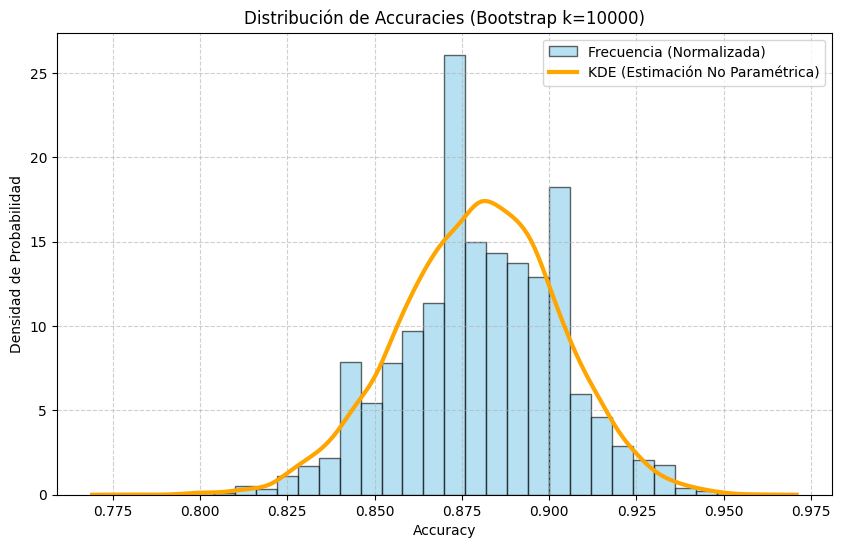

In [ ]:
# Graficamos el histograma de accuracies bootstrap
n_iterations = 10000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=15, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)')

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
import torch
import gc

# 1. Borrar variables que puedan estar ocupando memoria en el notebook
# (Si tienes variables globales de los experimentos anteriores, elimínalas)
# Por ejemplo, si tienes 'mejor_modelo', 'histories', etc. que no necesites:
# del mejor_modelo 

# 2. Recolección de basura de Python (elimina referencias huérfanas)
gc.collect()

# 3. Vaciar la caché de la GPU de PyTorch
torch.cuda.empty_cache()

print("🧹 Memoria de GPU liberada.")
print(f"Memoria reservada actual: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

🧹 Memoria de GPU liberada.
Memoria reservada actual: 0.12 GB
